<a href="https://colab.research.google.com/github/Linzhangcmingdan/vae_toy_case_moon/blob/main/medium_understanding_variational_autoencoders_vaes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 from sklearn.datasets import make_moons
X,y= make_moons(n_samples=200,noise=0.2,random_state=442)

In [ ]:
X.shape

(200, 2)

In [ ]:
y.shape

(200,)

In [ ]:
import os

import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

In [ ]:

from google.colab import drive
import os

gdrive_path='/content/gdrive/MyDrive/tu-delft'

# This will mount your google drive under 'MyDrive'
drive.mount('/content/gdrive', force_remount=True)
# In order to access the files in this notebook we have to navigate to the correct folder
os.chdir(gdrive_path)
# Check manually if all files are present
print(sorted(os.listdir()))


Mounted at /content/gdrive
['Medium_Understanding_Variational_Autoencoders (VAEs).ipynb']


In [ ]:
import os
os.chdir('/content/gdrive/MyDrive/tu-delft')
print("当前工作目录:", os.getcwd())


当前工作目录: /content/gdrive/MyDrive/tu-delft


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Installing PyTorch

In [ ]:
# Install a pip package in the current Jupyter kernel
import sys

# For google colab
!python -m pip install torch==2.2.2 torchvision==0.17.2 torchaudio==2.2.2 --index-url https://download.pytorch.org/whl/cu121

# For Linux and probably Windows (CPU)
#!{sys.executable} -m pip install torch==2.2.2 torchvision==0.17.2 torchaudio==2.2.2 --index-url https://download.pytorch.org/whl/cpu

# For Linux and probably Windows (Prerequisites: Nvidia GPU + CUDA toolkit 11.8)
# !{sys.executable} -m pip install torch==2.2.2+cu118 torchvision==0.17.2+cu118 torchaudio==2.2.2+cu118 --index-url https://download.pytorch.org/whl/cu118


# For OS X/Mac
# !{sys.executable} -m pip install torch==2.2.2 torchvision==0.17.2 torchaudio==2.2.2

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 757.3/757.3 MB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 114.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 94.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 91.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 51.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 37.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 16.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 37.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 17.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### Checking PyTorch Installation and Version

In [ ]:
import torch
import torchvision
print(f"PyTorch version Installed: {torch.__version__}\nTorchvision version Installed: {torchvision.__version__}\n")
if not torch.__version__.startswith("2.2"):
    print("you are using an another version of PyTorch. We expect PyTorch 2.2. You may continue using your version but it"
          " might cause dependency and compatibility issues.")
if not torchvision.__version__.startswith("0.17"):
    print("you are using an another version of torchvision. We expect torchvision 0.17. You can continue with your version but it"
          " might cause dependency and compatibility issues.")

PyTorch version Installed: 2.5.1+cu124
Torchvision version Installed: 0.20.1+cu124

you are using an another version of PyTorch. We expect PyTorch 2.2. You may continue using your version but it might cause dependency and compatibility issues.
you are using an another version of torchvision. We expect torchvision 0.17. You can continue with your version but it might cause dependency and compatibility issues.


Epoch 0, Loss: 2098.3062
Epoch 100, Loss: 1572.1956
Epoch 200, Loss: 1555.2869
Epoch 300, Loss: 1571.4319
Epoch 400, Loss: 1535.0881
Epoch 500, Loss: 1569.5522
Epoch 600, Loss: 1543.8313
Epoch 700, Loss: 1544.6465
Epoch 800, Loss: 1530.5093
Epoch 900, Loss: 1537.5852


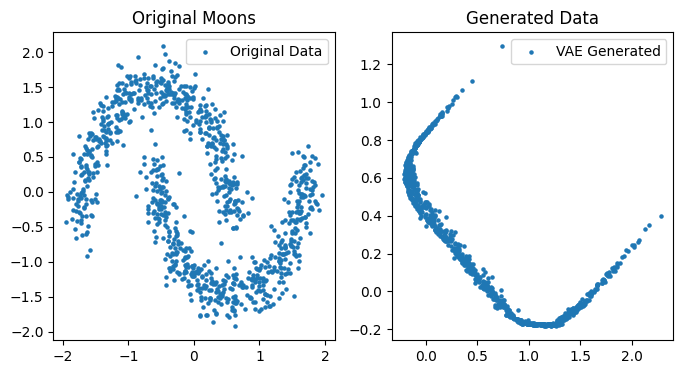

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

# 1. 生成 toycase 数据
X, _ = make_moons(n_samples=1000, noise=0.1)
scaler = StandardScaler()
X = scaler.fit_transform(X)
X = torch.tensor(X, dtype=torch.float32)

# 2. 定义 VAE 结构
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(VAE, self).__init__()
        self.fc1 = nn.Linear(input_dim, 16)
        self.fc2_mu = nn.Linear(16, latent_dim)
        self.fc2_logvar = nn.Linear(16, latent_dim)
        self.fc3 = nn.Linear(latent_dim, 16)
        self.fc4 = nn.Linear(16, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc2_mu(h)
        logvar = self.fc2_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc3(z))
        return self.fc4(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# 3. 训练 VAE
input_dim = 2
latent_dim = 2
vae = VAE(input_dim, latent_dim)
optimizer = optim.Adam(vae.parameters(), lr=0.01)

def loss_function(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss

epochs = 1000
for epoch in range(epochs):
    optimizer.zero_grad()
    recon_x, mu, logvar = vae(X)
    loss = loss_function(recon_x, X, mu, logvar)
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

# 4. 生成新数据
with torch.no_grad():
    z = torch.randn(1000, latent_dim)
    generated_data = vae.decode(z).numpy()
    generated_data = scaler.inverse_transform(generated_data)

# 5. 可视化结果
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], s=5, label='Original Data')
plt.legend()
plt.title("Original Moons")

plt.subplot(1, 2, 2)
plt.scatter(generated_data[:, 0], generated_data[:, 1], s=5, label='VAE Generated')
plt.legend()
plt.title("Generated Data")
plt.show()


## 1.4 Devices

When training a neural network, it is important to make sure that all the required tensors as well as the model are on the same device. Tensors can be moved between the CPU and GPU using `.to` method.

Let us check if a GPU is available. If it is available, we will assign it to `device` and move the tensor `x` to the GPU.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torch.utils.data.sampler import SubsetRandomSampler

import os
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'

%load_ext autoreload
%autoreload 2
%matplotlib inline

os.environ['KMP_DUPLICATE_LIB_OK']='True' # To prevent the kernel from dying.

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
!pip install expecttest

In [ ]:
# Initializing the Numpy Array
array_np = np.array([[1,2,3],[5,6,7]]) # A NumPy array

# Initializing the Tensor
array_ts = torch.tensor([[1,2,3],[4,5,6]]) # A Tensor

print("Variable array_np:\nDatatype: {}\nShape: {}".format(type(array_np), array_np.shape))
print("Values:\n", array_np)
print("\n\nVariable array_ts:\nDatatype {}\nShape: {}".format(type(array_ts), array_ts.shape))
print("Values:\n", array_ts)

Variable array_np:
Datatype: <class 'numpy.ndarray'>
Shape: (2, 3)
Values:
 [[1 2 3]
 [5 6 7]]


Variable array_ts:
Datatype <class 'torch.Tensor'>
Shape: torch.Size([2, 3])
Values:
 

AttributeError: module 'torch.onnx' has no attribute '_CAFFE2_ATEN_FALLBACK'

In [ ]:
x = torch.tensor([[1,2],[3,4]])
y = torch.tensor([[5,6],[7,8]])

# Elementwise Addition of the tensors
# [[ 6.0  8.0]
#  [10.0 12.0]]

# Addition - Syntax 1
print("x + y: \n{}".format(x + y))

# Addition - Syntax 2
print("x + y: \n{}".format(torch.add(x, y)))

# Addition - Syntax 3
result_add = torch.empty(2, 2)
torch.add(x, y, out=result_add)
print("x + y: \n{}".format(result_add))

ModuleNotFoundError: No module named 'expecttest'

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

print(f"Original device: {x.device}") # "cpu"

tensor = x.to(device)
print(f"Current device: {tensor.device}") #"cpu" or "cuda"

cpu
Original device: cpu
Current device: cpu


So `x` has been moved on to a CUDA device for those who have a GPU; otherwise it's still on the CPU.

<div class="alert alert-block alert-info"><b>Tip:</b> Try including the <b>.to(device)</b> calls in your codes. It is then easier to port the code to run on a GPU.</div>

# 2. Training a classifier with PyTorch

Now that we are introduced PyTorch tensors, we will look at how to use PyTorch to train neural networks. We will do the following steps:

1. Load data
2. Define a two-layer network
3. Define a loss function and optimizer
4. Train the network
5. Test the network

## 2.1 Loading Datasets

The general procedure of loading data is :
- Extract data from  source
- Transform the data into a suitable form (for example, to a Tensor)
- Put our data into an object to make it easy to access further on

### 2.1.1 Loading the Housing Price dataset

We'll use both our `DataLoader` class from the previous exercises and PyTorch's `DataLoader` to load the house price dataset that we used in Exercise 4 to classify the price of the houses.

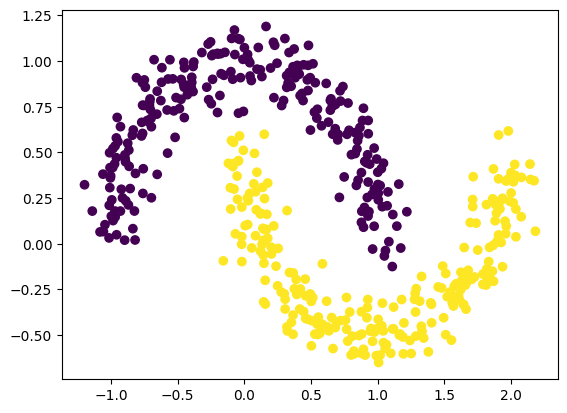

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=500, noise=0.1)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

#STEP 1: Importing Required Libraries
步骤1：导入所需库

In [ ]:
from keras.layers import Input, Dense
from keras.models import Model
from keras.datasets import mnist

import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

#STEP 2: Data Exploration  步骤2：数据探索

In [ ]:
#Load our MNIST dataset.
(XTrain, YTrain), (XTest, YTest) = mnist.load_data()

print('XTrain class = ',type(XTrain))
print('YTrain class = ',type(YTrain))

# shape of our dataset.
print('XTrain shape = ',XTrain.shape)
print('XTest shape = ',XTest.shape)
print('YTrain shape = ',YTrain.shape)
print('YTest shape = ',YTest.shape)
# Number of distinct values of our MNIST target
print('YTrain values = ',np.unique(YTrain))
print('YTest values = ',np.unique(YTest))
# Distribution of classes in our dataset.
unique, counts = np.unique(YTrain, return_counts=True)
print('YTrain distribution = ',dict(zip(unique, counts)))
unique, counts = np.unique(YTest, return_counts=True)
print('YTest distribution = ',dict(zip(unique, counts)))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
XTrain class =  <class 'numpy.ndarray'>
YTrain class =  <class 'numpy.ndarray'>
XTrain shape =  (60000, 28, 28)
XTest shape =  (10000, 28, 28)
YTrain shape =  (60000,)
YTest shape =  (10000,)
YTrain values =  [0 1 2 3 4 5 6 7 8 9]
YTest values =  [0 1 2 3 4 5 6 7 8 9]
YTrain distribution =  {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}
YTest distribution =  {0: 980, 1: 1135, 2: 1032, 3: 1010, 4: 982, 5: 892, 6: 958, 7: 1028, 8: 974, 9: 1009}


Shapes of the Dataset: We check the dimensions of the training and testing datasets. The training set contains 60,000 images, and the test set contains 10,000 images, each of size 28x28 pixels.
数据集的形状：我们检查培训和测试数据集的尺寸。该训练集包含60,000张图像，测试组包含10,000张图像，每张图像28x28像素。
Class Distribution: We analyze the distribution of classes (digits 0–9) in both training and testing sets to ensure that the dataset is balanced.
类别分布：我们分析了培训和测试集中类（数字0-9）的分布，以确保数据集平衡。

#STEP 3: Data Preprocessing
步骤3：数据预处理

In [ ]:
# Data normalization.
XTrain = XTrain.astype('float32') / 255
XTest = XTest.astype('float32') / 255
# data reshapping.
XTrain = XTrain.reshape((len(XTrain), np.prod(XTrain.shape[1:])))
XTest = XTest.reshape((len(XTest), np.prod(XTest.shape[1:])))

print (XTrain.shape)
print (XTest.shape)

(60000, 784)
(10000, 784)


#STEP 4: Building the Autoencoder
步骤4：构建自动编码器
We construct the autoencoder model, which consists of an encoder and a decoder. The encoder reduces the dimensionality of the input, while the decoder reconstructs the input from this compressed representation:

In [ ]:
InputModel = Input(shape=(784,))
EncodedLayer = Dense(32, activation='relu')(InputModel)
DecodedLayer = Dense(784, activation='sigmoid')(EncodedLayer)

AutoencoderModel = Model(InputModel, DecodedLayer)
# we can summarize our model.
AutoencoderModel.summary()

NameError: name 'Input' is not defined

##Input Layer: Accepts vectors of size 784.
接受尺寸784的向量。
##Encoder Layer:A dense layer with 32 neurons, applying ReLU activation.
编码层：具有32个神经元的致密层，应用了Relu激活
##Decoder Layer: Adense layer that reconstructs the input back to784 dimensions used sigmoid activation.
解码层：一个密集的层， 将输入重建为784个维度的密集层使用了Sigmoid 激活。

#STEP 5: Model Compilation and Training
步骤5：模型汇编和培训: We compile the model using the Adadelta optimizer and binary crossentropy loss function, which is suitable for our binary output:

In [ ]:
# Let's train the model using adadelta optimizer
AutoencoderModel.compile(optimizer='adadelta', loss='binary_crossentropy')

history = AutoencoderModel.fit(XTrain, XTrain,
                batch_size=256,
                epochs=100,
                shuffle=True,
                validation_data=(XTest, XTest))
# Make prediction to decode the digits
DecodeDigits = AutoencoderModel.predict(XTest)

NameError: name 'AutoencoderModel' is not defined

Traning: The model is trained for 100 epochs, using 256 samples per batch.训练：该模型经过100个时期的训练，每批次使用256个样本。

#STEP 6: Model Evaluation  步骤6：模型评估


After training, we can evaluate the model's performance by plotting the training and validation loss:训练后，我们可以通过绘制培训和验证损失来评估模型的性能。

In [ ]:
def plotmodelhistory(history):
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.title('Autoencoder Model loss')
  plt.ylabel('Loss')
  plt.xlabel('Epochs')
  plt.legend(['Train', 'Test'], loc ="upper left")
  plt.show()

# list all data in history
print(history.history.keys())
# visualization of the loss minimization during the training process
plotmodelhistory(history)

#STEP 7: Visualizing Results
步骤7：可视化结果
Finally, we visualize the original images alongside their reconstructed version to assess the performance of the autoencoder:
最后，我们将原始图像与其重建版本一起可视化，以评估自动编码器的性能：

In [ ]:
n=5
plt.figure(figsize=(20, 4))
for i in range(n):
  ax = plt.subplot(2, n, i+1)
  # input image
  plt.imshow(XTest[i].reshape(28, 28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)